<a href="https://colab.research.google.com/github/divyaH17/movie-sentiment-analyzer/blob/main/movie_sentiment_analyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install tensorflow matplotlib


In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt


In [3]:
from tensorflow.keras.datasets import imdb

# Only keep top 10,000 most common words
num_words = 10000
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=num_words)

print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000, Test samples: 25000


In [4]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

maxlen = 200  # max number of words per review

X_train = pad_sequences(X_train, maxlen=maxlen)
X_test = pad_sequences(X_test, maxlen=maxlen)

print("Shape of training data:", X_train.shape)


Shape of training data: (25000, 200)


In [5]:
model = keras.Sequential([
    layers.Embedding(input_dim=num_words, output_dim=64, input_length=maxlen),
    layers.LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = model.fit(
    X_train, y_train,
    epochs=3,
    batch_size=128,
    validation_split=0.2
)


Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 74s 440ms/step - accuracy: 0.6395 - loss: 0.6152 - val_accuracy: 0.8020 - val_loss: 0.4259
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 66s 424ms/step - accuracy: 0.8594 - loss: 0.3459 - val_accuracy: 0.8264 - val_loss: 0.3953
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 64s 406ms/step - accuracy: 0.8848 - loss: 0.2863 - val_accuracy: 0.8434 - val_loss: 0.3848


In [7]:
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc*100:.2f}%")


782/782 ━━━━━━━━━━━━━━━━━━━━ 36s 46ms/step - accuracy: 0.8380 - loss: 0.3889
Test Accuracy: 83.80%


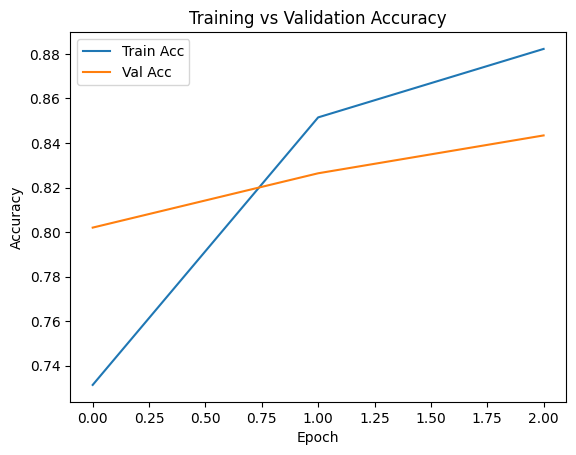

In [8]:
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


In [9]:
word_index = imdb.get_word_index()

reverse_word_index = {v: k for k, v in word_index.items()}

def encode_review(text):
    words = text.lower().split()
    encoded = [word_index.get(w, 2) for w in words]  # 2 = <UNK>
    return pad_sequences([encoded], maxlen=maxlen)

review = "The movie was amazing, absolutely wonderful acting and story!"
pred = model.predict(encode_review(review))
print("Review:", review)
print("Predicted Sentiment:", "😊 Positive" if pred[0][0] > 0.5 else "😞 Negative")


1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 708ms/step
Review: The movie was amazing, absolutely wonderful acting and story!
Predicted Sentiment: 😊 Positive
